In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # use GPU if available, else CPU
print("Using device:", device)


In [ ]:
# Load the rice classification dataset
data_df = pd.read_csv("/home/raj/Deep-learning/riceClassification.csv")
data_df.head()

## Preprocessing
Drop rows with missing values and remove the `id` column, since it's just a row identifier and carries no predictive signal.

In [ ]:
data_df.dropna(inplace=True)  # remove rows with missing values
data_df.drop(['id'], axis=1, inplace=True)  # id is just a row identifier, not a useful feature
print("Data shape after dropping NaN values and 'id' column:", data_df.shape)

In [82]:
data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [ ]:
# Check the class labels and how balanced they are
print(data_df["Class"].unique())
print(data_df["Class"].value_counts())

## Normalization
Scale each feature to the [0, 1] range by dividing by its own max absolute value, so features with naturally larger magnitudes (e.g. `Area`) don't dominate ones with smaller magnitudes (e.g. `Eccentricity`) during training.

In [ ]:
original_df = data_df.copy()  # keep an unnormalized copy for reference (used later for predicting on raw input)

for column in data_df.columns:
    data_df[column] = (data_df[column] / data_df[column].abs().max())  # scale each column to [0, 1] by its own max
data_df.head()

## Features and Target
Split the normalized dataframe into the feature matrix `X` (all columns except `Class`) and the target vector `y` (the `Class` column), then divide into train/validation/test sets.

In [85]:
X = np.array(data_df.iloc[:, :-1]) #iloc selects all rows and all columns except the last one (features)
y = np.array(data_df.iloc[:, -1]) #iloc selects all rows and only the last column (target variable)


In [86]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # train_test_split splits the dataset into training and testing sets, with 30% of the data reserved for testing. The random_state parameter ensures reproducibility of the split.
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.3, random_state=42) # Split the test set into test and validation sets

In [ ]:
# Confirm the sizes of the train/validation/test splits
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

## Dataset and DataLoader
Wrap the numpy arrays in a PyTorch `Dataset` (moving tensors to `device` up front) so `DataLoader` can batch and shuffle them during training.

In [ ]:
class dataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).to(device)  # move features to device once, up front
        self.y = torch.tensor(y, dtype=torch.float32).to(device)

    def __len__(self):
        return len(self.X)  # total number of samples

    def __getitem__(self, index):
        return self.X[index], self.y[index]  # a single (features, label) pair


In [ ]:
# Wrap each split in the custom Dataset so DataLoader can consume it
training_data = dataset(X_train, y_train)
validation_data = dataset(X_val, y_val)
testing_data = dataset(X_test, y_test)

In [ ]:
# Batch and shuffle each split; shuffling helps avoid learning order-dependent patterns
train_dataloader = DataLoader(training_data, batch_size=32, shuffle= True)
validation_dataloader = DataLoader(validation_data, batch_size=32, shuffle= True)
testing_dataloader = DataLoader(testing_data, batch_size=32, shuffle= True)


In [ ]:
# Peek at a single batch to sanity-check shapes and values
for x, y in train_dataloader:
    print(x)
    print("=====")
    print(y)
    break

## Model
A simple feed-forward network for binary classification: an input layer projecting the 10 features to a hidden size of 10, followed by a linear output layer and a sigmoid activation to produce a probability.

In [ ]:
Hidden_neuron = 10  # size of the hidden layer
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()

        self.input_layer = nn.Linear(X.shape[1], Hidden_neuron)  # project the 10 input features to the hidden size
        self.linear = nn.Linear(Hidden_neuron, 1)  # collapse hidden layer to a single output logit
        self.sigmoid = nn.Sigmoid()  # squash the logit into a probability in [0, 1]

    def forward(self, x):
        x = self.input_layer(x)
        x = self.linear(x)
        x = self.sigmoid(x)
        return x

model = MyModel().to(device)


In [ ]:
# Print the model's layers, output shapes, and parameter counts
summary(model, (X.shape[1],))

## Training
Use binary cross-entropy loss with the Adam optimizer, training for 10 epochs while tracking loss and accuracy on both the training and validation sets each epoch.

In [ ]:
criterian = nn.BCELoss()  # binary cross-entropy loss, matches the sigmoid output for binary classification
optimizer = Adam(model.parameters(), lr = 0.001)


In [ ]:
# Track loss/accuracy per epoch so they can be plotted later
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

In [ ]:
epochs = 10
for epoch in range(epochs):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_val = 0
    total_loss_val = 0

    model.train()  # enable training mode
    for data in train_dataloader:
        inputs, labels = data

        prediction = model(inputs).squeeze(1)  # drop the extra dim so shape matches labels
        batch_loss = criterian(prediction, labels)

        total_loss_train += batch_loss.item()
        total_acc_train += (prediction.round() == labels).sum().item()  # round probability to 0/1 to compare with labels

        batch_loss.backward()  # compute gradients
        optimizer.step()  # update model weights
        optimizer.zero_grad()  # reset gradients before the next batch

    model.eval()  # switch to evaluation mode for validation
    with torch.no_grad():  # no need to track gradients when just evaluating
        for data in validation_dataloader:
            inputs, labels = data

            prediction = model(inputs).squeeze(1)
            batch_loss = criterian(prediction, labels)

            total_loss_val += batch_loss.item()
            total_acc_val += (prediction.round() == labels).sum().item()

    total_loss_train_plot.append(round(total_loss_train/1000, 4))
    total_loss_validation_plot.append(round(total_loss_val/1000, 4))
    total_acc_train_plot.append(round(total_acc_train/len(training_data) * 100, 4))
    total_acc_validation_plot.append(round(total_acc_val/len(validation_data) * 100, 4))

    print(f'''Epoch no. {epoch+1} Train Loss: {round(total_loss_train/1000, 4)} Train Accuracy {round(total_acc_train/len(training_data)*100, 4)}
            Validation Loss: {round(total_loss_val/1000, 4)} Validation Accuracy: {round(total_acc_val/len(validation_data)*100, 4)}''')
    print("="*25)

## Evaluation
Run the trained model on the held-out test set (never seen during training or validation) to get an unbiased estimate of accuracy.

In [ ]:
with torch.no_grad():  # inference only, no need to track gradients
    total_loss_test = 0
    total_acc_test = 0
    for data in testing_dataloader:
        inputs, labels = data

        prediction = model(inputs).squeeze(1)
        batch_loss_test = criterian(prediction, labels).item()
        total_loss_test += batch_loss_test
        accuracy = ((prediction).round() ==labels).sum().item()
        total_acc_test += accuracy

print("accuracy: ", round(total_acc_test/len(testing_data)*100, 4) )

## Plots
Visualize training vs. validation loss and accuracy across epochs to check for overfitting or underfitting.

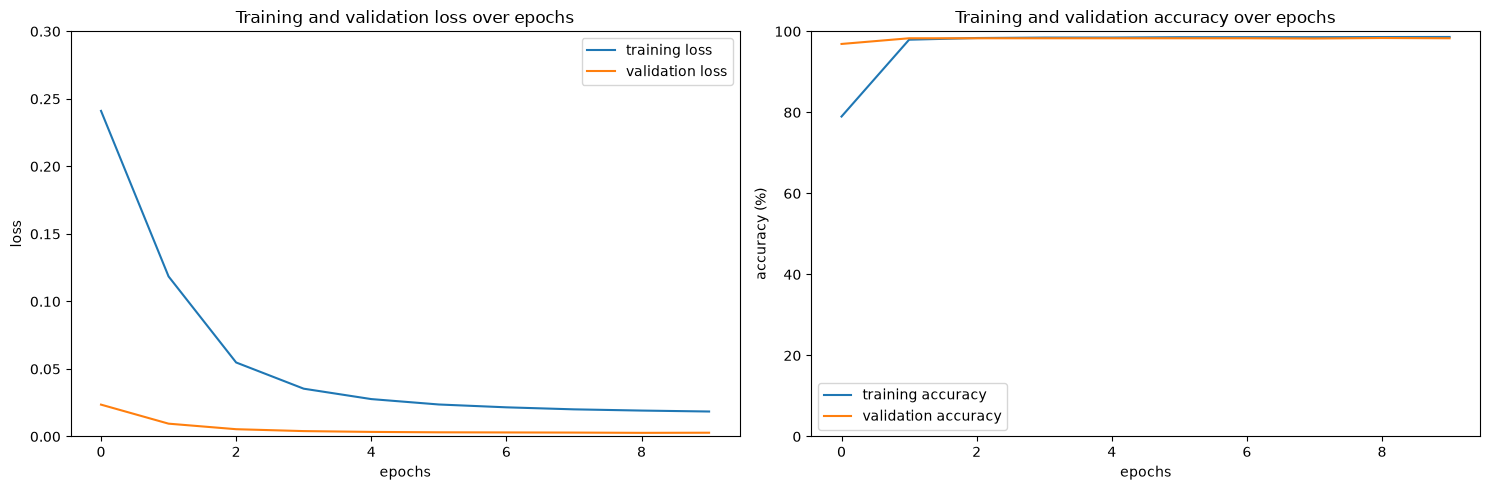

In [98]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# ---- Left subplot: loss ----
axs[0].plot(total_loss_train_plot, label="training loss")
axs[0].plot(total_loss_validation_plot, label="validation loss")
axs[0].set_title("Training and validation loss over epochs")
axs[0].set_xlabel("epochs")
axs[0].set_ylabel("loss")
axs[0].set_ylim([0, 0.3])
axs[0].legend()

# ---- Right subplot: accuracy ----
axs[1].plot(total_acc_train_plot, label="training accuracy")
axs[1].plot(total_acc_validation_plot, label="validation accuracy")
axs[1].set_title("Training and validation accuracy over epochs")
axs[1].set_xlabel("epochs")
axs[1].set_ylabel("accuracy (%)")
axs[1].set_ylim([0, 100])
axs[1].legend()

plt.tight_layout()
plt.show()


In [99]:
original_df


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1
...,...,...,...,...,...,...,...,...,...,...,...
18180,5853,148.624571,51.029281,0.939210,6008,86.326537,0.498594,332.960,0.663444,2.912535,0
18181,7585,169.593996,58.141659,0.939398,7806,98.272692,0.647461,385.506,0.641362,2.916910,0
18182,6365,154.777085,52.908085,0.939760,6531,90.023162,0.561287,342.253,0.682832,2.925396,0
18183,5960,151.397924,51.474600,0.940427,6189,87.112041,0.492399,343.371,0.635227,2.941216,0


## Predicting on a New Sample
Manually normalize a new rice grain's raw measurements using the same max values from `original_df` (so they're on the same scale the model was trained on), then run it through the model to get a class probability. Note: `EquivDiameter`, `Extent`, `Perimeter`, and `AspectRation` are left as 0 here since they weren't supplied for this example — in practice all 10 features should be provided for an accurate prediction.

In [ ]:
# Normalize a new sample's raw measurements using the same max values seen during training
Area = 2353 / original_df["Area"].abs().max()
MajorAxisLength = 81 / original_df["MajorAxisLength"].abs().max()
MinorAxisLength = 42 / original_df["MinorAxisLength"].abs().max()
Eccentricity = 32 / original_df["Eccentricity"].abs().max()
ConvexArea = 12 / original_df["ConvexArea"].abs().max()
Roundness = 677 / original_df["Roundness"].abs().max()

# EquivDiameter, Extent, Perimeter, and AspectRation are left as 0 placeholders (not provided for this example)
sample = torch.tensor([[Area, MajorAxisLength, MinorAxisLength, Eccentricity,
                        ConvexArea, Roundness, 0.0, 0.0, 0.0, 0.0]],
                       dtype=torch.float32).to(device)
model(sample)  # forward pass to get the predicted class probability